# Compact Featurewise Ridge Regression

This notebook is a standalone compact Ridge workflow. It loads one prepared Training Data artifact, uses the same compact descriptors, trains one shared model for geometry/appearance/densification, and then shows the selected multipliers with charts.

The notebook is organized so working cells and visualization cells are separate. Code comments explain why important steps exist, especially where the math can otherwise feel opaque.

## 0. Install Notebook Dependencies

Run this first in a fresh environment. `tqdm` gives progress bars. `pandas` and `matplotlib` are only for tables and charts; they do not change the model math.


In [1]:
# Optional install cell. Run this only if imports fail in the next cell.
# Running package installs may restart some notebook kernels.
# %pip install tqdm pandas matplotlib numpy


## 1. Configuration

Use this block to choose the prepared **Training Data artifact**. An artifact is the saved folder that contains `manifest.json` and `rows.json`; those two files are enough for this notebook to run without reading pipeline config files.

Set `TRAINING_DATA_ARTIFACT_DIR` when you want a fully portable run from a copied dataset folder. Leave it blank only when running inside this repo and you want the newest ready Training Data artifact.

`score_key` is the target value the model learns to predict. Here it is `relative_quality_score`, so higher means a better run relative to the baseline. `candidate_points` controls how many multiplier candidates are checked inside each compact group during prediction. A larger value searches more finely but takes longer.

In [2]:
from __future__ import annotations

import itertools
import json
import math
import time
from pathlib import Path
from typing import Any

import numpy as np
from tqdm.auto import tqdm
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

NOTEBOOK_ROOT = Path.cwd()
REPO_ROOT = NOTEBOOK_ROOT.parent if NOTEBOOK_ROOT.name == "notebooks" else NOTEBOOK_ROOT
DEFAULT_TRAINING_DATA_ROOT = REPO_ROOT / "bimba3d_backend" / "data" / "workflow" / "training_data"
OUT_DIR = (NOTEBOOK_ROOT / "_outputs") if NOTEBOOK_ROOT.name == "notebooks" else (NOTEBOOK_ROOT / "notebook_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# For a fully portable run, set this to the folder that contains manifest.json and rows.json.
# Leave it blank only when running inside this repo and you want to use TRAINING_DATA_ID/latest ready data.
TRAINING_DATA_ARTIFACT_DIR = ""
TRAINING_DATA_ID = ""

# This is the score column the model learns from.
SCORE_KEY = "relative_quality_score"

# Candidate points define the search resolution for each compact multiplier group.
CANDIDATE_POINTS = 21

# Ridge lambda controls regularization strength. These candidates are tested to choose the regularization strength.
RIDGE_LAMBDAS = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0]


print(f"Notebook root:       {NOTEBOOK_ROOT}")
print(f"Default data root:   {DEFAULT_TRAINING_DATA_ROOT}")
print(f"Notebook output dir: {OUT_DIR}")


Notebook root:       D:\bimba3d-re\notebooks
Default data root:   D:\bimba3d-re\bimba3d_backend\data\workflow\training_data
Notebook output dir: D:\bimba3d-re\notebooks\_outputs


## 2. Compact Schema

This block defines the compact schema used by this notebook.

A **descriptor** is one input feature that describes the project, such as image detail, coverage, blur risk, or vegetation. Compact featurewise intentionally uses only the compact scene descriptors listed here.

The model first predicts three compact multiplier groups: geometry, appearance, and densification. Those group choices are then expanded into the final per-parameter multipliers. `gsd_median` is log-transformed because scale values behave multiplicatively: changing from 0.02 to 0.04 is similar to changing from 0.10 to 0.20.

In [3]:
# These are the three compact multiplier groups used by this workflow.
# Each group controls several final training parameters together.
# The model predicts group multipliers first, then expands them to the final parameter multipliers.
COMPACT_MODEL_GROUP_KEYS = ["geometry_lr_mult", "appearance_lr_mult", "densification_mult"]

# Compact featurewise intentionally uses only the scene descriptors below.
# "intercept" is not a descriptor from data; it gives the model a baseline score offset.
COMPACT_FEATURE_KEYS = [
    "intercept",
    "gsd_median",
    "overlap_proxy",
    "coverage_spread",
    "camera_angle_bucket",
    "heading_consistency",
    "texture_density",
    "blur_motion_risk",
    "terrain_roughness_proxy",
    "vegetation_complexity_score",
    "vegetation_cover_percentage",
]

# GSD behaves multiplicatively: 0.02 to 0.04 is a similar scale change as 0.10 to 0.20.
# A log transform lets the model see those scale changes more evenly.
COMPACT_LOG_TRANSFORM_FEATURES = {"gsd_median"}
COMPACT_SCALER_STD_FLOOR = 0.01

COMPACT_GROUP_BOUNDS = {
    "geometry_lr_mult": (0.5, 2.0),
    "appearance_lr_mult": (0.5, 2.0),
    "densification_mult": (0.7, 1.4285714286),
}

# Prepared artifacts may contain older group names. These aliases keep the notebook compatible
# while still training the compact model on the current three group keys.
COMPACT_GROUP_BOUND_ALIASES = {
    "geometry_lr": "geometry_lr_mult",
    "geometry": "geometry_lr_mult",
    "appearance_lr": "appearance_lr_mult",
    "appearance": "appearance_lr_mult",
    "scale_lr": "densification_mult",
    "densification": "densification_mult",
    "densification_lr": "densification_mult",
}

COMPACT_PARAMETER_GROUPS = {
    "geometry_lr_mult": ["position_lr_init_mult", "scaling_lr_mult", "rotation_lr_mult"],
    "appearance_lr_mult": ["feature_lr_mult", "opacity_lr_mult", "lambda_dssim_mult"],
    "densification_mult": ["densify_grad_threshold_mult", "opacity_threshold_mult"],
}


def clamp_float(value: float, lo: float, hi: float) -> float:
    return max(lo, min(hi, float(value)))


def normalise_compact_group_bounds(bounds: dict[str, Any] | None = None) -> dict[str, tuple[float, float]]:
    """Return clean positive bounds for the compact multiplier search."""
    out = dict(COMPACT_GROUP_BOUNDS)
    if not isinstance(bounds, dict):
        return out
    for raw_key, raw_value in bounds.items():
        group_key = COMPACT_GROUP_BOUND_ALIASES.get(str(raw_key), str(raw_key))
        if group_key not in out or not isinstance(raw_value, (list, tuple)) or len(raw_value) < 2:
            continue
        try:
            lo = float(raw_value[0])
            hi = float(raw_value[1])
        except (TypeError, ValueError):
            continue
        if not math.isfinite(lo) or not math.isfinite(hi) or lo <= 0.0 or hi <= 0.0:
            continue
        if hi < lo:
            lo, hi = hi, lo
        out[group_key] = (lo, hi)
    return out


def _feature_float(features: dict[str, Any], key: str, default: float, *, positive: bool = False) -> float:
    value = features.get(key)
    if isinstance(value, bool):
        return default
    if isinstance(value, (int, float)):
        parsed = float(value)
        if math.isfinite(parsed) and (parsed > 0.0 if positive else True):
            return parsed
    return default


def compact_raw_feature(features: dict[str, Any], name: str) -> float:
    """Read one descriptor with built-in defaults for incomplete rows."""
    if name == "gsd_median":
        return _feature_float(features, "gsd_median", 0.05, positive=True)
    if name == "overlap_proxy":
        return _feature_float(features, "overlap_proxy", 0.5)
    if name == "coverage_spread":
        return _feature_float(features, "coverage_spread", 0.5)
    if name == "camera_angle_bucket":
        return _feature_float(features, "camera_angle_bucket", 0.0)
    if name == "heading_consistency":
        return _feature_float(features, "heading_consistency", 0.5)
    if name == "texture_density":
        return _feature_float(features, "texture_density", 0.5)
    if name == "blur_motion_risk":
        return _feature_float(features, "blur_motion_risk", 0.5)
    if name == "terrain_roughness_proxy":
        if "terrain_roughness_proxy" in features:
            return _feature_float(features, "terrain_roughness_proxy", 0.5)
        return _feature_float(features, "terrain_roughness", 0.5)
    if name == "vegetation_complexity_score":
        if "vegetation_complexity_score" in features:
            return _feature_float(features, "vegetation_complexity_score", 0.5)
        return _feature_float(features, "vegetation_complexity", 0.5)
    if name == "vegetation_cover_percentage":
        if "vegetation_cover_percentage" in features:
            return _feature_float(features, "vegetation_cover_percentage", 0.5)
        return _feature_float(features, "vegetation_cover", 0.5)
    return 0.0


def compact_transform_feature(name: str, value: float) -> float:
    return math.log(max(float(value), 1e-9)) if name in COMPACT_LOG_TRANSFORM_FEATURES else float(value)


def build_compact_feature_scaler(rows: list[dict[str, Any]]) -> dict[str, dict[str, float]]:
    """Fit the Ridge scaler from training rows.

    Ridge solves a linear system, so very different feature scales can dominate the solution.
    For that reason, compact Ridge scales descriptors. Compact MLP does not use this scaler.
    """
    values_by_feature = {name: [] for name in COMPACT_FEATURE_KEYS if name != "intercept"}
    for row in rows:
        features = row.get("x_features")
        if not isinstance(features, dict) or not features:
            continue
        for name in values_by_feature:
            values_by_feature[name].append(compact_transform_feature(name, compact_raw_feature(features, name)))
    scaler = {}
    for name, values in values_by_feature.items():
        if not values:
            scaler[name] = {"mean": 0.0, "std": 1.0}
        else:
            arr = np.array(values, dtype=np.float64)
            scaler[name] = {"mean": float(np.mean(arr)), "std": max(float(np.std(arr)), COMPACT_SCALER_STD_FLOOR)}
    return scaler


def build_compact_vector(features: dict[str, Any], scaler: dict[str, dict[str, float]] | None = None) -> np.ndarray:
    """Build the compact context vector used by both compact models."""
    values = []
    scaler = scaler or {}
    for name in COMPACT_FEATURE_KEYS:
        if name == "intercept":
            values.append(1.0)
            continue
        transformed = compact_transform_feature(name, compact_raw_feature(features, name))
        stats = scaler.get(name)
        if isinstance(stats, dict):
            std = max(float(stats.get("std", 1.0)), COMPACT_SCALER_STD_FLOOR)
            values.append((transformed - float(stats.get("mean", 0.0))) / std)
        else:
            values.append(transformed)
    return np.array(values, dtype=np.float64)


def compact_action_logs_from_multipliers(multipliers: dict[str, Any], bounds: dict[str, tuple[float, float]] | None = None) -> np.ndarray | None:
    """Convert stored parameter multipliers into the three compact log actions."""
    bounds = normalise_compact_group_bounds(bounds)
    logs = []
    for group_key in COMPACT_MODEL_GROUP_KEYS:
        direct = multipliers.get(group_key)
        value = float(direct) if isinstance(direct, (int, float)) and not isinstance(direct, bool) and float(direct) > 0 else None
        if value is None:
            # Older rows may store per-parameter multipliers instead of group multipliers.
            # Group members are averaged so compact training can still use the row.
            members = [
                float(multipliers[key])
                for key in COMPACT_PARAMETER_GROUPS[group_key]
                if isinstance(multipliers.get(key), (int, float)) and not isinstance(multipliers.get(key), bool) and float(multipliers[key]) > 0
            ]
            value = float(np.mean(members)) if members else None
        if value is None:
            return None
        lo, hi = bounds[group_key]
        logs.append(float(math.log(max(clamp_float(value, lo, hi), 1e-9))))
    return np.array(logs, dtype=np.float64)


def build_compact_score_design_vector(x_context: np.ndarray, action_logs: np.ndarray) -> np.ndarray:
    """Score features: context, action values, action curvature, and context-action interactions."""
    x = np.asarray(x_context, dtype=np.float64)
    a = np.asarray(action_logs, dtype=np.float64)
    interactions = np.concatenate([x[1:] * float(value) for value in a], axis=0)
    return np.concatenate([x, a, a * a, interactions], axis=0)


def expand_compact_group_multipliers(group_multipliers: dict[str, float]) -> tuple[dict[str, float], dict[str, float]]:
    """Expand three compact group choices into the final parameter multipliers used by training."""
    multipliers = {}
    log_multipliers = {}
    for group_key, member_keys in COMPACT_PARAMETER_GROUPS.items():
        group_mult = float(group_multipliers[group_key])
        group_log = float(math.log(max(group_mult, 1e-9)))
        for member_key in member_keys:
            multipliers[member_key] = group_mult
            log_multipliers[member_key] = group_log
    return multipliers, log_multipliers


print("Compact descriptors:")
display(pd.DataFrame({"descriptor": [key for key in COMPACT_FEATURE_KEYS if key != "intercept"]}))


Compact descriptors:


,descriptor
0,gsd_median
1,overlap_proxy
2,coverage_spread
3,camera_angle_bucket
4,heading_consistency
5,texture_density
6,blur_motion_risk
7,terrain_roughness_proxy
8,vegetation_complexity_score
9,vegetation_cover_percentage


## 3. Load Training Data

The notebook reads only the prepared Training Data artifact: `manifest.json` and `rows.json`.

The manifest must already contain the frozen training snapshot: multiplier bounds, base params, score key, and hard-cap information. **Base params** are the original training parameter values before multipliers are applied. Reading them from the artifact keeps final values tied to the dataset that was actually prepared.

In [4]:
def load_json(path: Path) -> Any:
    return json.loads(path.read_text(encoding="utf-8"))


def selected_training_data_artifact() -> Path:
    if TRAINING_DATA_ARTIFACT_DIR:
        artifact = Path(TRAINING_DATA_ARTIFACT_DIR).expanduser()
        if not artifact.exists():
            raise FileNotFoundError(f"TRAINING_DATA_ARTIFACT_DIR does not exist: {artifact}")
        return artifact
    if TRAINING_DATA_ID:
        artifact = DEFAULT_TRAINING_DATA_ROOT / TRAINING_DATA_ID
        if not artifact.exists():
            raise FileNotFoundError(f"TRAINING_DATA_ID was not found under {DEFAULT_TRAINING_DATA_ROOT}: {TRAINING_DATA_ID}")
        return artifact
    return latest_ready_training_data(DEFAULT_TRAINING_DATA_ROOT)


def latest_ready_training_data(root: Path) -> Path:
    manifests = []
    for manifest_path in root.glob("*/manifest.json"):
        manifest = load_json(manifest_path)
        if manifest.get("status") != "ready":
            continue
        stamp = manifest.get("last_built_at") or manifest.get("created_at") or ""
        manifests.append((stamp, manifest_path.parent))
    if not manifests:
        raise FileNotFoundError(
            f"No ready Training Data artifacts found under {root}. "
            "Set TRAINING_DATA_ARTIFACT_DIR to a prepared artifact folder for a portable run."
        )
    return sorted(manifests, key=lambda item: item[0], reverse=True)[0][1]


def first_dict(*values: Any) -> dict[str, Any]:
    for value in values:
        if isinstance(value, dict) and value:
            return dict(value)
    return {}


def first_number(source: dict[str, Any], keys: tuple[str, ...]) -> float | None:
    for key in keys:
        value = source.get(key)
        if isinstance(value, bool):
            continue
        if isinstance(value, (int, float)) and math.isfinite(float(value)):
            return float(value)
    return None


def clean_features(features: Any) -> dict[str, Any]:
    if not isinstance(features, dict):
        return {}
    # Missing-value diagnostics are audit fields, not descriptors used by compact featurewise models.
    return {key: value for key, value in features.items() if not str(key).lower().endswith("_missing")}


def normalise_training_row(row: dict[str, Any], source_path: Path) -> dict[str, Any] | None:
    if row.get("is_baseline_row"):
        return None
    features = clean_features(first_dict(row.get("x_features"), row.get("features"), row.get("project_features"), row.get("descriptors")))
    selected = first_dict(row.get("selected_multipliers"), row.get("multipliers"), row.get("y_multipliers"))
    score = first_number(row, (SCORE_KEY, "score", "quality_delta", "relative_score"))
    if not features or not selected or score is None:
        return None
    return {
        "project_id": row.get("project_id") or row.get("id") or source_path.stem,
        "project_name": row.get("project_name") or row.get("name") or source_path.stem,
        "run_id": row.get("run_id"),
        "phase": row.get("phase"),
        "x_features": features,
        "features": features,
        "selected_multipliers": selected,
        "selected_log_multipliers": row.get("selected_log_multipliers") or {},
        "metadata": row.get("metadata") or {},
        SCORE_KEY: score,
        "source_path": str(source_path),
    }


def bounds_from_training_data_manifest(manifest: dict[str, Any]) -> tuple[dict[str, tuple[float, float]], str]:
    build_summary = manifest.get("build_summary") if isinstance(manifest.get("build_summary"), dict) else {}
    raw_bounds = build_summary.get("log_multiplier_bounds")
    if not isinstance(raw_bounds, dict) or not raw_bounds:
        raise ValueError(
            "This Training Data artifact does not contain log_multiplier_bounds. "
            "Rebuild the dataset so the prepared data stores its training snapshot."
        )
    present_groups = {COMPACT_GROUP_BOUND_ALIASES.get(str(key), str(key)) for key in raw_bounds}
    missing = [group for group in COMPACT_MODEL_GROUP_KEYS if group not in present_groups]
    if missing:
        raise ValueError(f"Training Data artifact is missing compact multiplier bounds for: {missing}")
    source = str(build_summary.get("log_multiplier_bounds_source") or "training_data_manifest")
    return normalise_compact_group_bounds(raw_bounds), source


def base_params_from_training_data_manifest(manifest: dict[str, Any]) -> tuple[dict[str, float], str]:
    build_summary = manifest.get("build_summary") if isinstance(manifest.get("build_summary"), dict) else {}
    snapshot = build_summary.get("training_data_config_snapshot") if isinstance(build_summary.get("training_data_config_snapshot"), dict) else {}
    raw_params = build_summary.get("base_params") if isinstance(build_summary.get("base_params"), dict) else snapshot.get("base_params")
    if not isinstance(raw_params, dict) or not raw_params:
        raise ValueError(
            "This Training Data artifact does not contain base_params. "
            "Rebuild the dataset so final parameter values are computed from the prepared data, not notebook defaults."
        )
    required = [
        "feature_lr",
        "position_lr_init",
        "scaling_lr",
        "opacity_lr",
        "rotation_lr",
        "densify_grad_threshold",
        "opacity_threshold",
        "lambda_dssim",
    ]
    out: dict[str, float] = {}
    missing: list[str] = []
    for key in required:
        value = raw_params.get(key)
        if isinstance(value, bool) or not isinstance(value, (int, float)) or not math.isfinite(float(value)):
            missing.append(key)
        else:
            out[key] = float(value)
    if missing:
        raise ValueError(f"Training Data artifact is missing numeric base_params for: {missing}")
    source = str(build_summary.get("base_params_source") or snapshot.get("base_params_source") or "training_data_manifest")
    return out, source


artifact_dir = selected_training_data_artifact()
manifest = load_json(artifact_dir / "manifest.json")
raw_rows = load_json(artifact_dir / "rows.json")
training_rows = [row for raw in raw_rows if isinstance(raw, dict) for row in [normalise_training_row(raw, artifact_dir / "rows.json")] if row]

# Prediction preview uses the training rows. This keeps the notebook independent from pipeline config files.
test_projects = []
seen_projects = set()
for row in training_rows:
    if row["project_id"] in seen_projects:
        continue
    test_projects.append({"project_id": row["project_id"], "project_name": row["project_name"], "features": row["features"], "source_path": row["source_path"]})
    seen_projects.add(row["project_id"])

GROUP_BOUNDS, GROUP_BOUNDS_SOURCE = bounds_from_training_data_manifest(manifest)
# Base params come from the prepared artifact so final values cannot drift with later app config changes.
BASE_PARAMS, BASE_PARAMS_SOURCE = base_params_from_training_data_manifest(manifest)
build_summary = manifest.get("build_summary") or {}
print("Training Data artifact")
print("----------------------")
print(f"artifact folder:     {artifact_dir}")
print(f"id:                  {manifest.get('training_data_id')}")
print(f"name:                {manifest.get('name')}")
print(f"rows in artifact:    {len(raw_rows)}")
print(f"training rows used:  {len(training_rows)}")
print(f"source pipeline:     {manifest.get('source_pipeline_id')}")
print(f"score key:           {build_summary.get('score_key', SCORE_KEY)}")
print(f"hard-cap rows:       {build_summary.get('hard_cap_penalty_rows', 0)}")
print(f"hard-cap penalty:    {build_summary.get('hard_cap_penalty')}")
print(f"gaussian hard cap:   {build_summary.get('gaussian_hard_cap')}")
print(f"multiplier bounds:   {GROUP_BOUNDS_SOURCE} -> {GROUP_BOUNDS}")
print(f"base params:         {BASE_PARAMS_SOURCE} -> {BASE_PARAMS}")

if training_rows:
    display(pd.DataFrame([{"project": r["project_name"], "run_id": r.get("run_id"), "score": r[SCORE_KEY], "hard_cap": bool(r.get("metadata", {}).get("is_hard_cap_penalty_row"))} for r in training_rows[:12]]))
else:
    raise ValueError("No valid training rows found in the selected Training Data artifact.")


Training Data artifact
----------------------
artifact folder:     D:\bimba3d-re\bimba3d_backend\data\workflow\training_data\training_data_20260710_183008_final_offline_data_june_27-training-data
id:                  training_data_20260710_183008_final_offline_data_june_27-training-data
name:                Final_offline_data_June_27 Training Data
rows in artifact:    697
training rows used:  697
source pipeline:     pipeline_55776ebd244e
score key:           relative_quality_score
hard-cap rows:       44
hard-cap penalty:    -0.5373449585805301
gaussian hard cap:   6000000
multiplier bounds:   source_pipeline.fixed_log_space_bounds_snapshot -> {'geometry_lr_mult': (0.2, 5.0), 'appearance_lr_mult': (0.2, 5.0), 'densification_mult': (0.7, 1.43)}
base params:         built_in_base_params_snapshot -> {'feature_lr': 0.0025, 'position_lr_init': 0.00016, 'scaling_lr': 0.005, 'opacity_lr': 0.05, 'rotation_lr': 0.001, 'densify_grad_threshold': 0.0002, 'opacity_threshold': 0.005, 'lambda_dssim'

,project,run_id,score,hard_cap
0,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run10_20260710_035153,0.017791,False
1,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run11_20260706_205654,0.044199,False
2,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run12_20260707_004251,-0.212381,False
3,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run13_20260707_121531,-0.018172,False
4,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run14_20260708_011209,-0.007883,False
5,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run15_20260708_104004,-0.000125,False
6,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run1_20260708_221316,-0.185065,False
7,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run2_20260702_174506,-0.010570,False
8,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run3_20260709_083747,-0.029192,False
9,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run4_20260703_161832,-0.069004,False


## 4. Inspect Descriptor Data

Before training, this block prints the exact rows the model will use.

It shows score range, hard-cap penalty rows, compact descriptor statistics, and the compact group multipliers produced from the stored selected multipliers. A **hard-cap penalty row** is a training example added only during Training Data build/rebuild when a run hit the Gaussian hard cap; it uses the dataset's lowest non-hard-cap score so the model learns that this region is poor.

In [5]:
if not training_rows:
    print("No descriptor table to display.")
else:
    descriptor_rows = []
    multiplier_rows = []
    for row in training_rows:
        record = {
            "project": row["project_name"],
            "run_id": row.get("run_id"),
            "score": row[SCORE_KEY],
            "hard_cap_penalty_row": bool(row.get("metadata", {}).get("is_hard_cap_penalty_row")),
        }
        for key in COMPACT_FEATURE_KEYS:
            if key != "intercept":
                record[key] = compact_raw_feature(row["features"], key)
        descriptor_rows.append(record)

        # These compact group multipliers are what the model learns from.
        # If a row stores per-parameter multipliers, the schema converts them into group values.
        logs = compact_action_logs_from_multipliers(row["selected_multipliers"], bounds=GROUP_BOUNDS)
        if logs is not None:
            for group, log_value in zip(COMPACT_MODEL_GROUP_KEYS, logs):
                multiplier_rows.append({
                    "project": row["project_name"],
                    "group": group,
                    "log_multiplier": float(log_value),
                    "multiplier": float(math.exp(float(log_value))),
                    "hard_cap_penalty_row": bool(row.get("metadata", {}).get("is_hard_cap_penalty_row")),
                })

    df_descriptors = pd.DataFrame(descriptor_rows)
    df_multipliers = pd.DataFrame(multiplier_rows)

    print("Dataset summary")
    display(pd.DataFrame([{
        "training_rows": len(training_rows),
        "preview_projects": len(test_projects),
        "hard_cap_penalty_rows": int(df_descriptors["hard_cap_penalty_row"].sum()),
        "score_min": float(df_descriptors["score"].min()),
        "score_mean": float(df_descriptors["score"].mean()),
        "score_max": float(df_descriptors["score"].max()),
        "bounds_source": GROUP_BOUNDS_SOURCE,
    }]))

    print("First rows used for training")
    display(df_descriptors[["project", "run_id", "score", "hard_cap_penalty_row"]].head(20))

    print("Compact descriptor summary")
    display(df_descriptors[[key for key in COMPACT_FEATURE_KEYS if key != "intercept"]].describe().T)

    print("Selected compact multiplier summary")
    if df_multipliers.empty:
        print("No valid compact group multipliers were found.")
    else:
        display(df_multipliers.groupby("group")[["multiplier", "log_multiplier"]].describe())


Dataset summary


,training_rows,preview_projects,hard_cap_penalty_rows,score_min,score_mean,score_max,bounds_source
0,697,46,44,-0.537345,-0.089034,0.129706,source_pipeline.fixed_log_space_bounds_snapshot


First rows used for training


,project,run_id,score,hard_cap_penalty_row
0,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run10_20260710_035153,0.017791,False
1,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run11_20260706_205654,0.044199,False
2,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run12_20260707_004251,-0.212381,False
3,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run13_20260707_121531,-0.018172,False
4,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run14_20260708_011209,-0.007883,False
5,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run15_20260708_104004,-0.000125,False
6,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run1_20260708_221316,-0.185065,False
7,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run2_20260702_174506,-0.010570,False
8,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run3_20260709_083747,-0.029192,False
9,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run4_20260703_161832,-0.069004,False


Compact descriptor summary


,count,mean,std,min,25%,50%,75%,max
gsd_median,697.0,0.052878,0.030258,0.005859,0.027313,0.050000,0.065380,0.176198
overlap_proxy,697.0,0.832701,0.120906,0.343786,0.815433,0.861470,0.898922,0.997376
coverage_spread,697.0,0.300557,0.230802,0.000000,0.134644,0.256319,0.396294,0.846018
camera_angle_bucket,697.0,2.000000,0.000000,2.000000,2.000000,2.000000,2.000000,2.000000
heading_consistency,697.0,0.642234,0.210865,0.246113,0.471299,0.630403,0.795009,0.998522
texture_density,697.0,0.161627,0.054916,0.058230,0.121738,0.155658,0.200575,0.307915
blur_motion_risk,697.0,0.874085,0.044493,0.750591,0.842909,0.876361,0.909638,0.951663
terrain_roughness_proxy,697.0,0.731156,0.189940,0.204930,0.604486,0.734147,0.869910,1.000000
vegetation_complexity_score,697.0,0.151198,0.094012,0.033249,0.090830,0.132072,0.203144,0.542578
vegetation_cover_percentage,697.0,0.142860,0.166704,0.000081,0.019816,0.086873,0.222371,0.865777


Selected compact multiplier summary


multiplier                                          \
                        count      mean       std       min       25%   
group                                                                   
appearance_lr_mult      697.0  1.523382  1.298948  0.212147  0.453281   
densification_mult      697.0  1.024230  0.216792  0.719046  0.809815   
geometry_lr_mult        697.0  1.498588  1.326091  0.206734  0.387391   

                                                 log_multiplier            \
                         50%       75%       max          count      mean   
group                                                                       
appearance_lr_mult  0.905098  2.430068  4.488197          697.0  0.025754   
densification_mult  1.008529  1.215659  1.429005          697.0  0.001552   
geometry_lr_mult    1.032342  2.152866  4.871202          697.0 -0.001325   

                                                                                
                         std       min       25%       50%       75%       max  
group                                                                           
appearance_lr_mult  0.926539 -1.550476 -0.791242 -0.099712  0.887919  1.501451  
densification_mult  0.212067 -0.329830 -0.210949  0.008493  0.195286  0.356978  
geometry_lr_mult    0.936833 -1.576321 -0.948320  0.031830  0.766800  1.583341

## 5. Visualize Descriptor And Score Distributions

These charts are intentionally separate from the training code. They help explain the data and catch unusual rows, but they do not change the trained model.

The score histogram shows the target distribution. The descriptor histograms show whether the compact inputs have enough variation for a model to learn useful relationships.

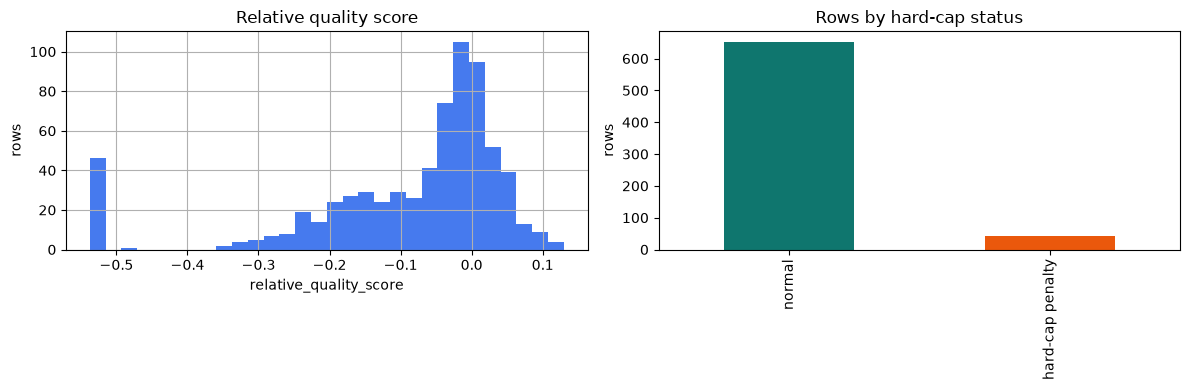

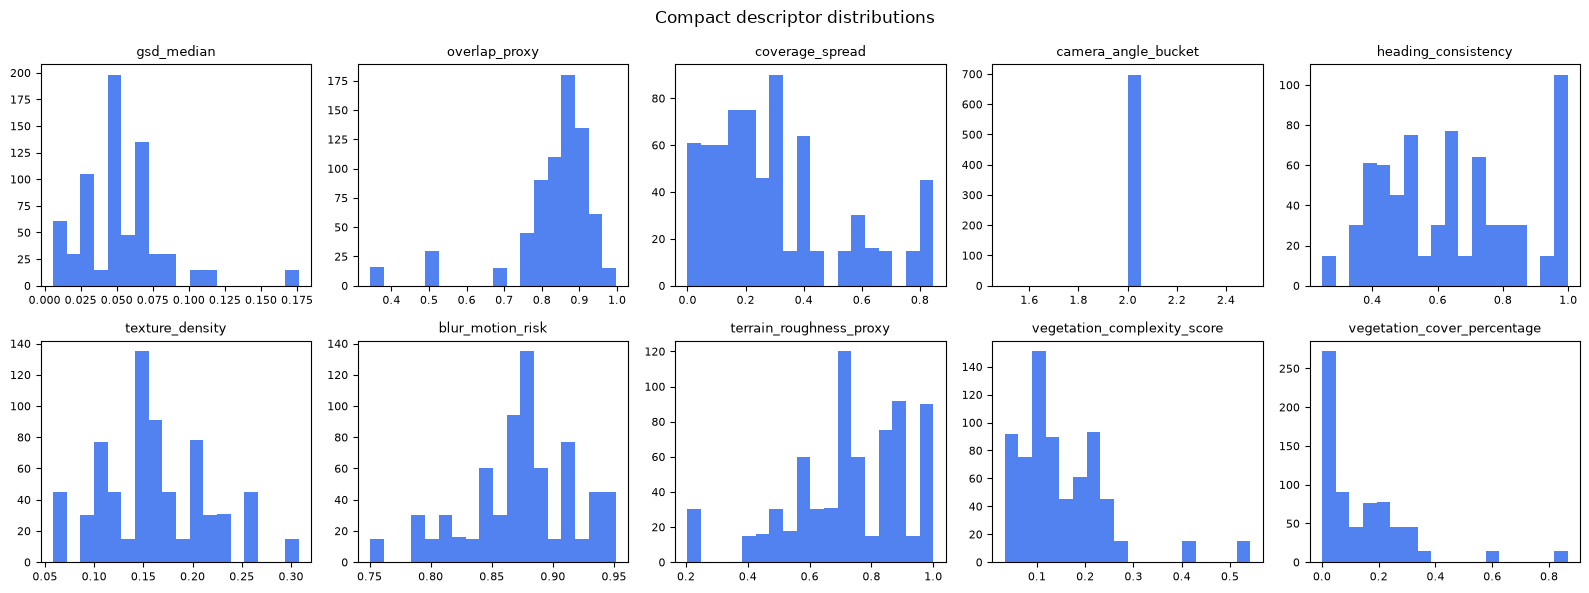

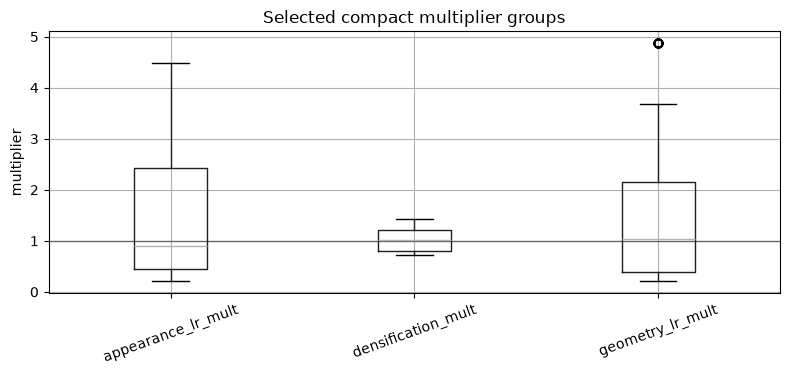

In [6]:
if not training_rows:
    print("No descriptors to visualize.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    df_descriptors["score"].hist(ax=axes[0], bins=30, color="#2563eb", alpha=0.85)
    axes[0].set_title("Relative quality score")
    axes[0].set_xlabel(SCORE_KEY)
    axes[0].set_ylabel("rows")

    if "hard_cap_penalty_row" in df_descriptors:
        counts = df_descriptors["hard_cap_penalty_row"].map({False: "normal", True: "hard-cap penalty"}).value_counts()
        counts.plot(kind="bar", ax=axes[1], color=["#0f766e", "#ea580c"][: len(counts)])
        axes[1].set_title("Rows by hard-cap status")
        axes[1].set_xlabel("")
        axes[1].set_ylabel("rows")
    fig.tight_layout()
    plt.show()

    numeric_cols = [key for key in COMPACT_FEATURE_KEYS if key != "intercept"]
    fig, axes = plt.subplots(2, 5, figsize=(16, 6))
    axes = axes.ravel()
    for ax, col in zip(axes, numeric_cols):
        ax.hist(df_descriptors[col].dropna(), bins=18, color="#2563eb", alpha=0.8)
        ax.set_title(col, fontsize=9)
        ax.tick_params(labelsize=8)
    fig.suptitle("Compact descriptor distributions")
    fig.tight_layout()
    plt.show()

    if not df_multipliers.empty:
        fig, ax = plt.subplots(figsize=(8, 4))
        df_multipliers.boxplot(column="multiplier", by="group", ax=ax, rot=20)
        ax.axhline(1.0, color="#111827", linewidth=1, alpha=0.5)
        ax.set_title("Selected compact multiplier groups")
        ax.set_xlabel("")
        ax.set_ylabel("multiplier")
        fig.suptitle("")
        fig.tight_layout()
        plt.show()


## 6. Train Compact Ridge

This is the working training block. It implements the compact Ridge path: fit a scaler from the training descriptors, build the compact score design vector, update the Ridge normal equations, and select the lambda with the lowest MSE.

A **scaler** stores the mean and standard deviation of each descriptor so features with different numeric ranges are comparable. **Ridge lambda** is the regularization strength; it discourages overly large weights so the model is less likely to overfit. **MSE** means mean squared error, the average squared difference between predicted and actual scores.

In [7]:
def empty_compact_ridge_model(lambda_ridge: float, scaler: dict[str, dict[str, float]], candidate_points: int, bounds: dict[str, tuple[float, float]]) -> dict[str, Any]:
    """Create the Ridge normal-equation state used by this notebook."""
    # The design includes context, three actions, action curvature, and descriptor-action interactions.
    d_x = len(build_compact_vector({}, scaler))
    d_phi = d_x + len(COMPACT_MODEL_GROUP_KEYS) + len(COMPACT_MODEL_GROUP_KEYS) + (d_x - 1) * len(COMPACT_MODEL_GROUP_KEYS)
    return {
        "version": 1,
        "model_family": "compact_featurewise_ridge_regression",
        "mode": "exif_compact_featurewise",
        "lambda_ridge": float(lambda_ridge),
        "runs": 0,
        "score_mean": 0.0,
        "feature_scaler": scaler,
        "candidate_points": int(max(5, candidate_points)),
        "log_multiplier_bounds": {key: [float(bounds[key][0]), float(bounds[key][1])] for key in COMPACT_MODEL_GROUP_KEYS},
        "action_space": "joint_log_multiplier",
        "design": "x_plus_three_actions_plus_action2_plus_xa",
        # Ridge regularization starts as lambda * I before any rows are added.
        "A": (np.eye(d_phi, dtype=np.float64) * float(lambda_ridge)).tolist(),
        "b": np.zeros(d_phi, dtype=np.float64).tolist(),
        "n": 0,
        "design_dim": d_phi,
    }


def solve_theta(model: dict[str, Any]) -> np.ndarray:
    A = np.array(model.get("A", []), dtype=np.float64)
    b = np.array(model.get("b", []), dtype=np.float64)
    try:
        return np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        return np.linalg.pinv(A) @ b


def compute_compact_ridge_metrics(model: dict[str, Any], rows: list[dict[str, Any]], score_key: str, group_bounds: dict[str, Any] | None = None) -> dict[str, Any]:
    bounds = normalise_compact_group_bounds(group_bounds or model.get("log_multiplier_bounds"))
    scaler = model.get("feature_scaler") if isinstance(model.get("feature_scaler"), dict) else {}
    theta = solve_theta(model)
    residuals = []
    targets = []
    for row in rows:
        score = row.get(score_key)
        action_logs = compact_action_logs_from_multipliers(row.get("selected_multipliers", {}), bounds=bounds)
        if action_logs is None or not isinstance(score, (int, float)):
            continue
        pred = float(build_compact_score_design_vector(build_compact_vector(row["x_features"], scaler), action_logs) @ theta)
        residuals.append(pred - float(score))
        targets.append(float(score))
    if not residuals:
        return {"mse": float("inf"), "rmse": float("inf"), "mae": float("inf"), "r_squared": 0.0, "samples": 0, "lambda_search_mse": float("inf")}
    arr = np.array(residuals, dtype=np.float64)
    target_arr = np.array(targets, dtype=np.float64)
    mse = float(np.mean(arr * arr))
    ss_tot = float(np.sum((target_arr - float(np.mean(target_arr))) ** 2))
    ss_res = float(np.sum(arr * arr))
    return {"mse": mse, "rmse": float(math.sqrt(mse)), "mae": float(np.mean(np.abs(arr))), "r_squared": 1.0 - (ss_res / ss_tot) if ss_tot > 1e-10 else 0.0, "samples": len(residuals), "lambda_search_mse": mse}


def train_compact_featurewise_ridge_model(rows: list[dict[str, Any]], score_key: str, lambda_ridge: float, candidate_points: int, group_bounds: dict[str, Any] | None = None):
    bounds = normalise_compact_group_bounds(group_bounds)
    # Ridge is scale-sensitive, so this workflow fits a scaler before building design vectors.
    scaler = build_compact_feature_scaler(rows)
    model = empty_compact_ridge_model(lambda_ridge, scaler, candidate_points, bounds)
    score_sum = 0.0
    runs = 0
    for row in rows:
        score = row.get(score_key)
        action_logs = compact_action_logs_from_multipliers(row.get("selected_multipliers", {}), bounds=bounds)
        if action_logs is None or not isinstance(score, (int, float)) or not math.isfinite(float(score)):
            continue
        phi = build_compact_score_design_vector(build_compact_vector(row["x_features"], scaler), action_logs)
        # Each row adds phi*phi^T and score*phi to the normal equations.
        model["A"] = (np.array(model["A"], dtype=np.float64) + np.outer(phi, phi)).tolist()
        model["b"] = (np.array(model["b"], dtype=np.float64) + float(score) * phi).tolist()
        model["n"] = int(model.get("n", 0)) + 1
        runs += 1
        score_sum += float(score)
    model["runs"] = runs
    model["score_mean"] = score_sum / runs if runs else 0.0
    metrics = compute_compact_ridge_metrics(model, rows, score_key=score_key, group_bounds=bounds)
    return model, metrics, float(np.linalg.norm(solve_theta(model)))


ridge_results = []
if not training_rows:
    print("Skipping Ridge training because no rows were found.")
else:
    print("Compact Ridge training status")
    print("-----------------------------")
    print(f"Training rows          : {len(training_rows)}")
    print(f"Lambda candidates      : {RIDGE_LAMBDAS}")
    print(f"Candidate grid points  : {CANDIDATE_POINTS}")
    # The selected lambda is the one with the lowest training-fit MSE for this compact model.
    for lam in tqdm(RIDGE_LAMBDAS, desc="Compact Ridge lambda search", unit="lambda"):
        model, metrics, theta_norm = train_compact_featurewise_ridge_model(training_rows, SCORE_KEY, lam, CANDIDATE_POINTS, group_bounds=GROUP_BOUNDS)
        ridge_results.append({"lambda": lam, "model": model, "metrics": metrics, "theta_norm": theta_norm})
        print(f"lambda={float(lam):g}  lambda_search_mse={float(metrics['lambda_search_mse']):.6f}  theta_norm={theta_norm:.6f}")
    best = min(ridge_results, key=lambda item: item["metrics"]["lambda_search_mse"])
    compact_ridge_model = best["model"]
    compact_ridge_metrics = best["metrics"]
    model_path = OUT_DIR / "compact_featurewise_ridge_model.json"
    model_path.write_text(json.dumps({"schema": "compact_featurewise_ridge_regression_v1", "model": compact_ridge_model, "metrics": compact_ridge_metrics}, indent=2), encoding="utf-8")
    print("\nCompact Ridge training complete")
    print("-------------------------------")
    display(pd.DataFrame([{"lambda": r["lambda"], **r["metrics"], "theta_norm": r["theta_norm"]} for r in ridge_results]))
    print(f"Selected lambda: {best['lambda']}")
    print(f"Best metrics: {json.dumps(compact_ridge_metrics, indent=2)}")
    print(f"Saved model: {model_path}")


Compact Ridge training status
-----------------------------
Training rows          : 697
Lambda candidates      : [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0]
Candidate grid points  : 21


Compact Ridge lambda search:   0%|          | 0/7 [00:00<?, ?lambda/s]

lambda=0.1  lambda_search_mse=0.010969  theta_norm=0.808455


lambda=0.5  lambda_search_mse=0.011097  theta_norm=0.548917


lambda=1  lambda_search_mse=0.011231  theta_norm=0.411833


...

lambda=5  lambda_search_mse=0.011615  theta_norm=0.190776


lambda=10  lambda_search_mse=0.011763  theta_norm=0.146487


lambda=20  lambda_search_mse=0.011897  theta_norm=0.121238

Compact Ridge training complete
-------------------------------


,lambda,mse,rmse,mae,r_squared,samples,lambda_search_mse,theta_norm
0,0.1,0.010969,0.104734,0.068646,0.513217,697,0.010969,0.808455
1,0.5,0.011097,0.105344,0.068833,0.507522,697,0.011097,0.548917
2,1.0,0.011231,0.105977,0.069235,0.501589,697,0.011231,0.411833
3,2.0,0.011397,0.106758,0.069834,0.494217,697,0.011397,0.294182
4,5.0,0.011615,0.107775,0.070535,0.484534,697,0.011615,0.190776
5,10.0,0.011763,0.108458,0.070788,0.477983,697,0.011763,0.146487
6,20.0,0.011897,0.109073,0.070782,0.472041,697,0.011897,0.121238


Selected lambda: 0.1
Best metrics: {
  "mse": 0.010969106726507758,
  "rmse": 0.10473350336214175,
  "mae": 0.06864599154783275,
  "r_squared": 0.5132167904528764,
  "samples": 697,
  "lambda_search_mse": 0.010969106726507758
}
Saved model: D:\bimba3d-re\notebooks\_outputs\compact_featurewise_ridge_model.json


## 7. Visualize Ridge Lambda Search

This chart shows why one Ridge lambda was selected.

Lower MSE means the model fit the prepared Training Data better under the same compact design. If several lambdas are very close, prefer the simpler/smoother model rather than reading tiny differences as meaningful.

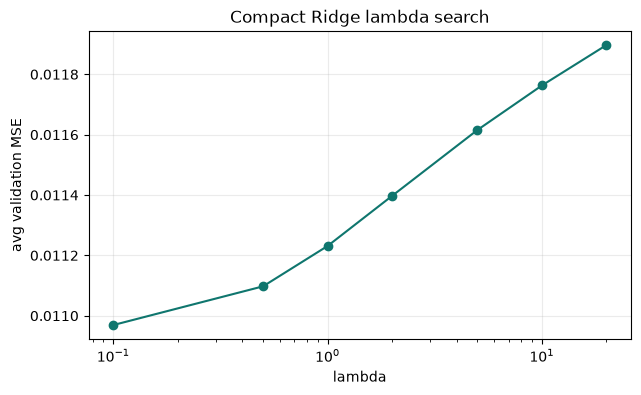

In [8]:
if not ridge_results:
    print("No Ridge metrics to visualize.")
else:
    df_ridge = pd.DataFrame([{"lambda": r["lambda"], **r["metrics"], "theta_norm": r["theta_norm"]} for r in ridge_results])
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(df_ridge["lambda"], df_ridge["lambda_search_mse"], marker="o", color="#0f766e")
    ax.set_xscale("log")
    ax.set_xlabel("lambda")
    ax.set_ylabel("lambda-search MSE")
    ax.set_title("Compact Ridge lambda search")
    ax.grid(True, alpha=0.25)
    plt.show()


## 8. Predict Multipliers

This block performs compact inference.

A **candidate grid** is the list of multiplier combinations the model will score. The notebook builds that grid from the bounds stored in Training Data, scores every joint candidate, selects the best one, and expands the three compact group choices into final parameter multipliers.

In [9]:
def candidate_logs_by_group(candidate_points: int, bounds: dict[str, tuple[float, float]], source: dict[str, Any] | None = None) -> dict[str, np.ndarray]:
    """Return candidate log multipliers for the joint search grid."""
    # The search happens in log space because multipliers are naturally multiplicative.
    # Equal spacing in log space treats 0.5 -> 1.0 similarly to 1.0 -> 2.0.
    out = {}
    for group in COMPACT_MODEL_GROUP_KEYS:
        lo, hi = bounds[group]
        raw = source.get(group) if isinstance(source, dict) else None
        if isinstance(raw, list) and raw:
            values = [clamp_float(float(value), math.log(lo), math.log(hi)) for value in raw if isinstance(value, (int, float))]
            out[group] = np.array(values or [0.0], dtype=np.float64)
        else:
            out[group] = np.linspace(math.log(lo), math.log(hi), int(max(5, candidate_points)), dtype=np.float64)
    return out


def candidate_checks_by_group(candidates_by_group: dict[str, np.ndarray], combos: list[tuple[float, ...]], scores: list[float], selected_logs: dict[str, float]) -> dict[str, list[dict[str, Any]]]:
    """Summarize each group's candidates for charting and debugging."""
    # The model scores joint combinations. For a one-dimensional chart we keep,
    # for each group candidate, the best score among combinations that include it.
    checks = {}
    for group_index, group in enumerate(COMPACT_MODEL_GROUP_KEYS):
        rows = []
        for candidate_log in candidates_by_group[group]:
            matching_scores = [scores[index] for index, combo in enumerate(combos) if abs(float(combo[group_index]) - float(candidate_log)) < 1e-12]
            score = float(max(matching_scores)) if matching_scores else 0.0
            rows.append({"candidate_log_multiplier": float(candidate_log), "candidate_multiplier": float(math.exp(float(candidate_log))), "predicted_score": score, "selected": bool(abs(float(candidate_log) - float(selected_logs[group])) < 1e-12)})
        checks[group] = rows
    return checks


def final_parameter_values(base_params: dict[str, float], multipliers: dict[str, float]) -> dict[str, float]:
    """Apply group multipliers to base training params so final values are visible."""
    return {
        "feature_lr": base_params["feature_lr"] * multipliers["feature_lr_mult"],
        "position_lr_init": base_params["position_lr_init"] * multipliers["position_lr_init_mult"],
        "scaling_lr": base_params["scaling_lr"] * multipliers["scaling_lr_mult"],
        "opacity_lr": base_params["opacity_lr"] * multipliers["opacity_lr_mult"],
        "rotation_lr": base_params["rotation_lr"] * multipliers["rotation_lr_mult"],
        "densify_grad_threshold": base_params["densify_grad_threshold"] * multipliers["densify_grad_threshold_mult"],
        "opacity_threshold": base_params["opacity_threshold"] * multipliers["opacity_threshold_mult"],
        "lambda_dssim": base_params["lambda_dssim"] * multipliers["lambda_dssim_mult"],
    }



def select_compact_ridge_from_model(model: dict[str, Any], x_features: dict[str, Any], candidate_log_multipliers_by_group: dict[str, Any] | None = None) -> dict[str, Any]:
    bounds = normalise_compact_group_bounds(model.get("log_multiplier_bounds"))
    candidates_by_group = candidate_logs_by_group(int(model.get("candidate_points", CANDIDATE_POINTS)), bounds, candidate_log_multipliers_by_group)
    combos = list(itertools.product(*(candidates_by_group[group] for group in COMPACT_MODEL_GROUP_KEYS)))
    x = build_compact_vector(x_features, model.get("feature_scaler") if isinstance(model.get("feature_scaler"), dict) else {})
    theta = solve_theta(model)
    scores = [float(build_compact_score_design_vector(x, np.array(combo, dtype=np.float64)) @ theta) for combo in combos]
    spread = float(max(scores) - min(scores)) if scores else 0.0
    if spread < 1e-6 or not scores:
        selected_logs = np.zeros(len(COMPACT_MODEL_GROUP_KEYS), dtype=np.float64)
        selected_score = scores[len(scores) // 2] if scores else 0.0
        has_signal = False
    else:
        best_idx = int(np.argmax(scores))
        selected_logs = np.array(combos[best_idx], dtype=np.float64)
        selected_score = float(scores[best_idx])
        has_signal = True
    group_multipliers = {}
    group_log_multipliers = {}
    for index, group in enumerate(COMPACT_MODEL_GROUP_KEYS):
        lo, hi = bounds[group]
        mult = clamp_float(float(math.exp(float(selected_logs[index]))), lo, hi)
        group_multipliers[group] = mult
        group_log_multipliers[group] = float(math.log(max(mult, 1e-9)))
    selected_multipliers, selected_log_multipliers = expand_compact_group_multipliers(group_multipliers)
    return {
        "selected_preset": "compact_featurewise_ridge_regression",
        "selected_multipliers": selected_multipliers,
        "selected_log_multipliers": selected_log_multipliers,
        "group_multipliers": group_multipliers,
        "group_log_multipliers": group_log_multipliers,
        "selected_score": selected_score,
        "has_signal": has_signal,
        "score_spreads": {group: spread for group in COMPACT_MODEL_GROUP_KEYS},
        "candidate_score_checks": candidate_checks_by_group(candidates_by_group, combos, scores, group_log_multipliers),
    }


prediction_rows = []
if "compact_ridge_model" not in globals() or not test_projects:
    print("No trained compact Ridge model or no preview projects.")
else:
    for project in test_projects:
        result = select_compact_ridge_from_model(compact_ridge_model, project["features"])
        prediction_rows.append({**project, **result, "final_values": final_parameter_values(BASE_PARAMS, result["selected_multipliers"])})
    preview_path = OUT_DIR / "compact_ridge_prediction_preview.json"
    preview_path.write_text(json.dumps({"rows": prediction_rows}, indent=2), encoding="utf-8")
    print(f"Prediction rows: {len(prediction_rows)}")
    print(f"Saved preview: {preview_path}")


Prediction rows: 46
Saved preview: D:\bimba3d-re\notebooks\_outputs\compact_ridge_prediction_preview.json


## 9. Prediction Table

The table shows the selected compact group multipliers and the final parameter values that would be used by training.

A multiplier of `1.0` means no change from the base value. Values above `1.0` increase that parameter; values below `1.0` reduce it.

In [10]:
if not prediction_rows:
    print("No predictions to display.")
else:
    summary_rows = []
    for row in prediction_rows:
        summary = {"project": row["project_name"], "selected_score": row.get("selected_score")}
        summary.update({f"group_{key}": value for key, value in row["group_multipliers"].items()})
        summary.update({f"final_{key}": value for key, value in row["final_values"].items()})
        summary_rows.append(summary)
    df_predictions = pd.DataFrame(summary_rows)
    display(df_predictions)


,project,selected_score,group_geometry_lr_mult,group_appearance_lr_mult,group_densification_mult,final_feature_lr,final_position_lr_init,final_scaling_lr,final_opacity_lr,final_rotation_lr,final_densify_grad_threshold,final_opacity_threshold,final_lambda_dssim
0,1-Montreal-City-Hall,0.087825,2.626528,0.851340,1.43,0.002128,0.000420,0.013133,0.042567,0.002627,0.000286,0.00715,0.170268
1,10_Holy_Ghost_Ukrainian_Church,0.074376,1.174619,1.000000,1.43,0.002500,0.000188,0.005873,0.050000,0.001175,0.000286,0.00715,0.200000
2,11-St-George-Church,0.070839,1.379730,1.000000,1.43,0.002500,0.000221,0.006899,0.050000,0.001380,0.000286,0.00715,0.200000
3,13-Murugan-Temple,0.057904,0.851340,0.851340,1.43,0.002128,0.000136,0.004257,0.042567,0.000851,0.000286,0.00715,0.170268
4,14-Hindu-Mandir,0.134101,1.000000,1.174619,0.70,0.002937,0.000160,0.005000,0.058731,0.001000,0.000140,0.00350,0.234924
5,15-Congregation-Shaar-Hashomayim,0.071678,1.379730,0.851340,1.43,0.002128,0.000221,0.006899,0.042567,0.001380,0.000286,0.00715,0.170268
6,16-Mosque,0.072429,1.620657,0.851340,1.43,0.002128,0.000259,0.008103,0.042567,0.001621,0.000286,0.00715,0.170268
7,17-Shaughnessy-Mansion,0.109300,1.379730,1.174619,0.70,0.002937,0.000221,0.006899,0.058731,0.001380,0.000140,0.00350,0.234924
8,2-Resurrection-Chapel,0.089386,1.379730,1.000000,0.70,0.002500,0.000221,0.006899,0.050000,0.001380,0.000140,0.00350,0.200000
9,3-Maison_Louis-Hippolyte_Lafontaine,0.129224,1.379730,1.174619,0.70,0.002937,0.000221,0.006899,0.058731,0.001380,0.000140,0.00350,0.234924


## 10. Visualize Selected Multipliers

This chart compares the selected compact group multipliers across preview projects.

The horizontal line at `1.0` means no change from the base parameter value. Big jumps between projects usually mean the descriptors are pushing the model toward different training behavior.

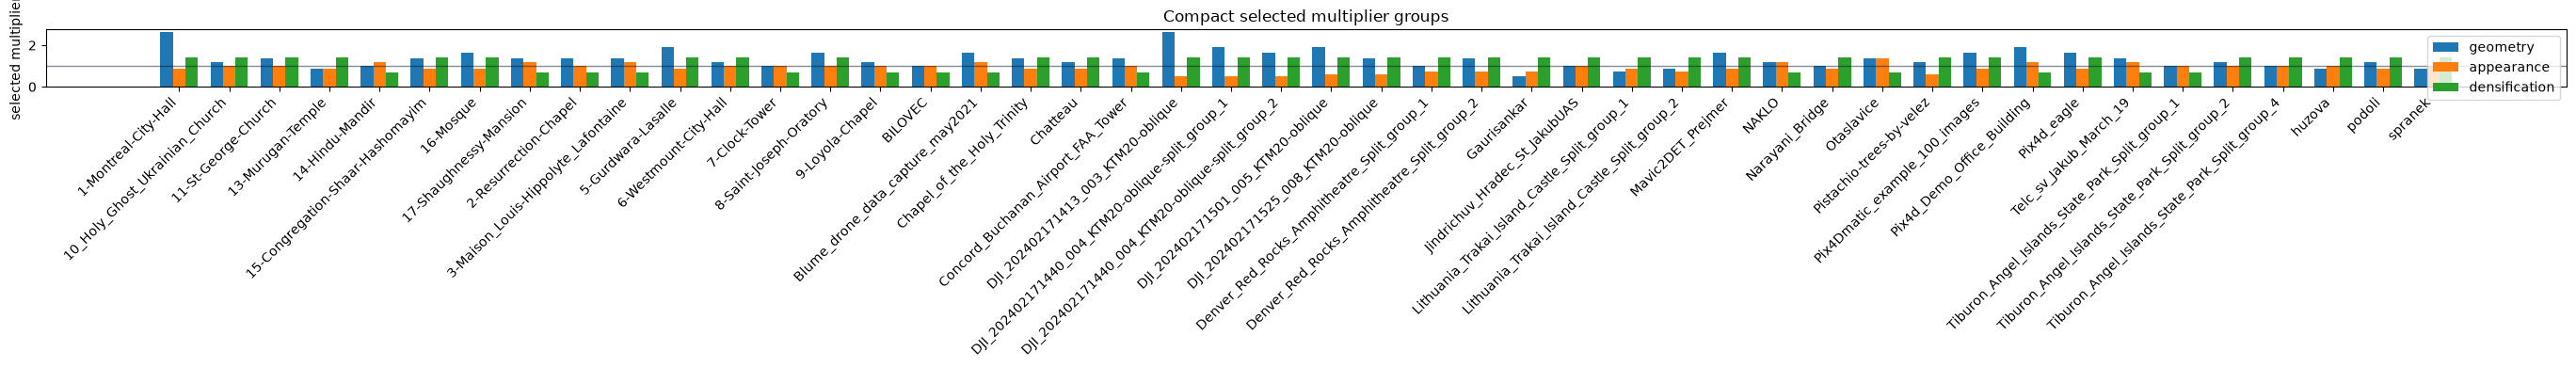

In [11]:
if not prediction_rows:
    print("No predictions to visualize.")
else:
    labels = [row["project_name"] for row in prediction_rows]
    x = np.arange(len(labels))
    width = 0.25
    fig, ax = plt.subplots(figsize=(max(8, len(labels) * 0.6), 4))
    ax.bar(x - width, [row["group_multipliers"]["geometry_lr_mult"] for row in prediction_rows], width, label="geometry")
    ax.bar(x, [row["group_multipliers"]["appearance_lr_mult"] for row in prediction_rows], width, label="appearance")
    ax.bar(x + width, [row["group_multipliers"]["densification_mult"] for row in prediction_rows], width, label="densification")
    ax.axhline(1.0, color="#111827", linewidth=1, alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("selected multiplier")
    ax.set_title("Compact selected multiplier groups")
    ax.legend()
    fig.tight_layout()
    plt.show()


## 11. Candidate Multiplier Curves

For one preview project, this chart shows how the model scored candidate values in each compact group. The red point marks the selected candidate.

The curve is a one-group view of a joint search: for each candidate value in one group, the chart shows the best score found among combinations that include that value.

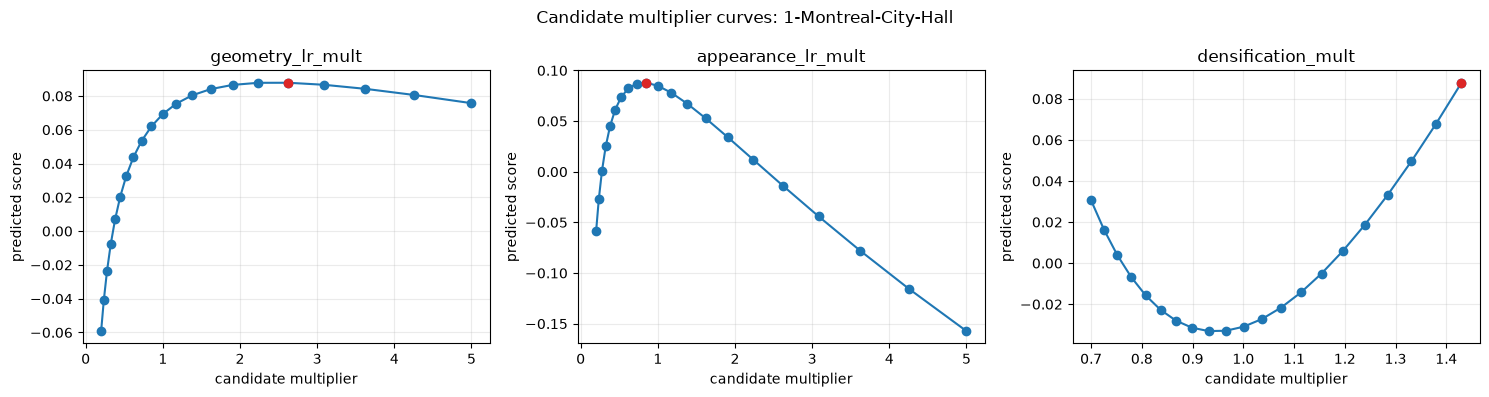

In [12]:
PROJECT_NAME = prediction_rows[0]["project_name"] if prediction_rows else None
if not prediction_rows:
    print("No prediction rows available.")
else:
    selected_row = next((row for row in prediction_rows if row["project_name"] == PROJECT_NAME), prediction_rows[0])
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, group in zip(axes, COMPACT_MODEL_GROUP_KEYS):
        df_curve = pd.DataFrame(selected_row["candidate_score_checks"][group])
        ax.plot(df_curve["candidate_multiplier"], df_curve["predicted_score"], marker="o", linewidth=1.5)
        selected = df_curve[df_curve["selected"]]
        if not selected.empty:
            ax.scatter(selected["candidate_multiplier"], selected["predicted_score"], color="#dc2626", zorder=5, label="selected")
        ax.set_title(group)
        ax.set_xlabel("candidate multiplier")
        ax.set_ylabel("predicted score")
        ax.grid(True, alpha=0.25)
    fig.suptitle(f"Candidate multiplier curves: {selected_row['project_name']}")
    fig.tight_layout()
    plt.show()


## 12. Final Notebook Summary

This final cell prints the important facts from the run in one place: which Training Data artifact was used, which settings were frozen inside it, where the notebook artifact was saved, and the first preview prediction.

Use this summary when comparing runs or checking the saved notebook outputs.

In [13]:
summary = {
    "training_data_id": manifest.get("training_data_id"),
    "training_rows": len(training_rows),
    "score_key": build_summary.get("score_key", SCORE_KEY),
    "bounds_source": GROUP_BOUNDS_SOURCE,
    "bounds": GROUP_BOUNDS,
    "selected_lambda": best["lambda"] if ridge_results else None,
    "training_samples_in_model": compact_ridge_model.get("runs") if ridge_results else None,
    "model_path": str(model_path) if "model_path" in globals() else None,
}
print("Compact Ridge notebook summary")
print("------------------------------")
display(pd.DataFrame([summary]))

if prediction_rows:
    print("First preview prediction")
    first = prediction_rows[0]
    display(pd.DataFrame([{
        "project": first["project_name"],
        "selected_score": first.get("selected_score"),
        **first["group_multipliers"],
    }]))
    print("Final parameter values for first preview prediction")
    display(pd.DataFrame([first["final_values"]]).T.rename(columns={0: "value"}))


Compact Ridge notebook summary
------------------------------


,training_data_id,training_rows,score_key,bounds_source,bounds,selected_lambda,training_samples_in_model,model_path
0,training_data_20260710_183008_final_offline_da...,697,relative_quality_score,source_pipeline.fixed_log_space_bounds_snapshot,"{'geometry_lr_mult': (0.2, 5.0), 'appearance_l...",0.1,697,D:\bimba3d-re\notebooks\_outputs\compact_featu...


First preview prediction


,project,selected_score,geometry_lr_mult,appearance_lr_mult,densification_mult
0,1-Montreal-City-Hall,0.087825,2.626528,0.85134,1.43


Final parameter values for first preview prediction


,value
feature_lr,0.002128
position_lr_init,0.000420
scaling_lr,0.013133
opacity_lr,0.042567
rotation_lr,0.002627
densify_grad_threshold,0.000286
opacity_threshold,0.007150
lambda_dssim,0.170268
